# 多项式回归（Polynomial Regression）

当特征与目标之间呈曲线关系时，可以先生成多项式特征，再使用线性回归。重点理解欠拟合、合适拟合与过拟合。

**建议学习方法：** 从上到下逐格运行；先观察输出，再修改参数并重新运行。代码固定了随机种子，便于复现实验结果。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文字体设置：按顺序尝试本机字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)


X 的形状: (120, 1)
y 的形状: (120,)


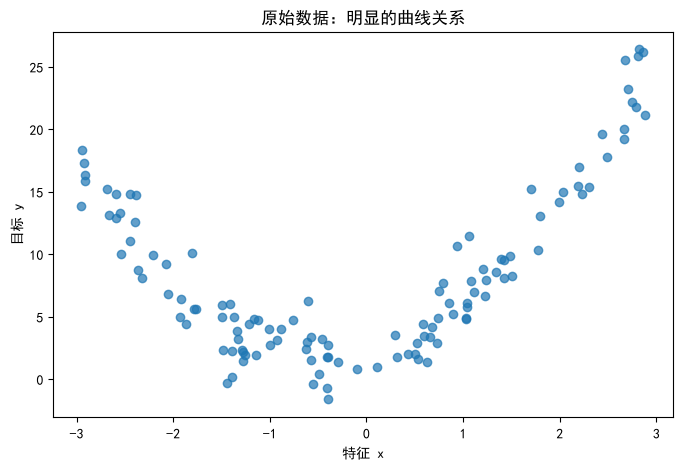

[[-1.92446633]
 [ 1.80002089]
 [ 0.31624245]
 [-0.62067791]
 [-2.20970983]
 [ 2.19177455]
 [-2.05636075]
 [-1.14127284]
 [-1.25972681]
 [ 2.22848421]
 [ 1.03621797]
 [ 1.78008838]
 [-1.49719261]
 [ 0.7492446 ]
 [ 0.4304759 ]
 [ 1.99698226]
 [ 2.43652236]
 [-2.92705937]
 [ 1.04411951]
 [-2.68898521]
 [ 0.29315199]
 [-1.27420363]
 [-1.1593404 ]
 [-0.88224898]
 [ 0.72775469]
 [-0.99570021]
 [ 1.3961943 ]
 [-0.57283569]
 [-2.5898808 ]
 [ 1.70255905]
 [-1.28545005]
 [-0.40339872]
 [ 1.1126633 ]
 [-1.00526306]
 [-2.66048606]
 [-0.75647372]
 [ 2.6666915 ]
 [ 0.85040638]
 [ 1.02887489]
 [ 0.79369292]
 [-1.80604717]
 [-0.48999682]
 [ 1.50563879]
 [-2.39176261]
 [-1.33288334]
 [-1.34208535]
 [-0.40788643]
 [ 2.88221245]
 [-2.59498472]
 [ 0.11220597]
 [-1.92381191]
 [ 2.82405927]
 [-2.32017897]
 [-0.57839399]
 [ 1.42730991]
 [ 1.22732657]
 [-0.46362818]
 [-0.92085499]
 [-0.61432573]
 [-1.41434242]
 [-1.76800237]
 [-0.10176181]
 [-1.38879746]
 [-1.27523001]
 [ 0.94053638]
 [ 2.81122399]
 [ 0.62182

In [17]:
# ========== 1. 生成一条带噪声的二次曲线 ==========
n_samples = 120
X = np.random.uniform(-3, 3, size=(n_samples, 1))
noise = np.random.normal(0, 1.8, size=n_samples)
y = 2.0 + 1.5 * X[:, 0] + 2.2 * X[:, 0] ** 2 + noise  #X[:, 0]把二维变一维，取第0列所有行

print('X 的形状:', X.shape)
print('y 的形状:', y.shape)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, alpha=0.7)
plt.xlabel('特征 x')
plt.ylabel('目标 y')
plt.title('原始数据：明显的曲线关系')
plt.show()
print(X[:,0:1],X[:,0:1].shape)#这样子表示的还是原本的X

In [11]:
# ========== 2. 划分训练集和测试集 ==========
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print('训练集:', X_train.shape, '测试集:', X_test.shape)

训练集: (90, 1) 测试集: (30, 1)


In [31]:
# ========== 3. 建立不同次数的多项式回归 ==========
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#PolynomialFeatures include_bias=False当dgree=2时只生成[x, x²]若=True则还要生成个1[1, x, x²]
#但是后面的 LinearRegression()会学习截距，所以说不用再添加截距
def build_model(degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

results = []
models = {} #用来把训练好的三个模型用字典保存起来
for degree in [1, 2, 10]:
    model = build_model(degree)       
    model.fit(X_train, y_train)
#比如 degree=2 时：原来的：X=[x]首先转换成：X_{poly}=[x,x^2]然后标准化：[x,x^2]={标准化后的}x{标准化后的}x^2]
#最后 LinearRegression 学习：y=w_0+w_1x+w_2x^2
    models[degree] = model

    for name, X_part, y_part in [
        ('训练集', X_train, y_train), ('测试集', X_test, y_test)
    ]:
#第一轮：name = '训练集' X_part = X_train y_part = y_train
        pred = model.predict(X_part)
        results.append({
            '次数': degree,
            '数据集': name,
            'RMSE': np.sqrt(mean_squared_error(y_part, pred)),
            'R²': r2_score(y_part, pred)
        })
#训练集和测试集都测来防止过拟合
#results.append把这次结果都保存下来
result_df = pd.DataFrame(results)
print(result_df.round(4))
print(models)

   次数  数据集    RMSE      R²
0   1  训练集  6.1283  0.1973
1   1  测试集  7.1793  0.1797
2   2  训练集  1.8819  0.9243
3   2  测试集  1.4630  0.9659
4  10  训练集  1.8072  0.9302
5  10  测试集  1.5702  0.9608
{1: Pipeline(steps=[('poly', PolynomialFeatures(degree=1, include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())]), 2: Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())]), 10: Pipeline(steps=[('poly', PolynomialFeatures(degree=10, include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])}


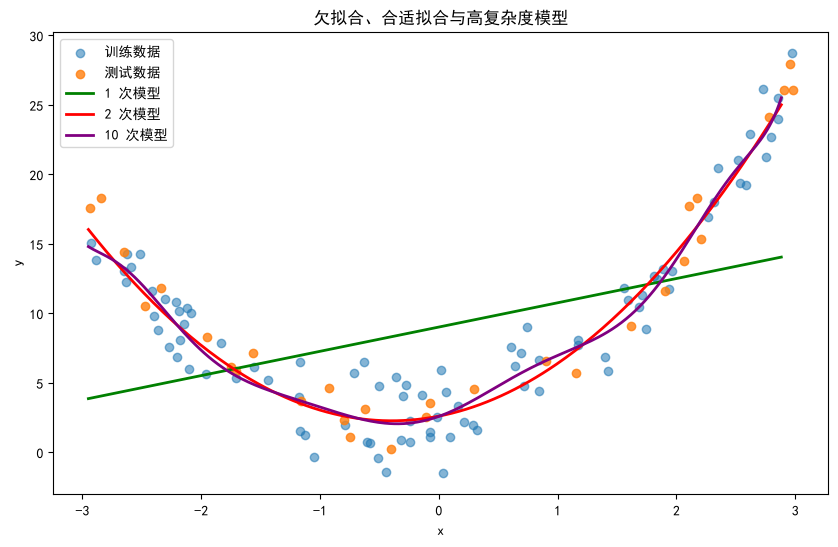

In [32]:
# ========== 4. 可视化三种复杂度 ==========
X_line = np.linspace(X.min(), X.max(),300).reshape(-1, 1)
#reshape(-1, 1)把一个一维数组变成“n 行 1 列”的二维数组-1意思是：这一维你帮我自动算。
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.55, label='训练数据')
plt.scatter(X_test[:, 0], y_test, alpha=0.8, label='测试数据')
for degree, color in zip([1, 2, 10], ['green', 'red', 'purple']):
    plt.plot(
        X_line[:, 0], models[degree].predict(X_line),
        color=color, linewidth=2, label=f'{degree} 次模型'
    )
plt.xlabel('x')
plt.ylabel('y')
plt.title('欠拟合、合适拟合与高复杂度模型')
plt.legend()
plt.show()


In [33]:
# ========== 5. 用二次模型预测新数据 ==========
best_model = models[2]
new_X = np.array([[-2.0], [0.0], [2.0]])
new_y = best_model.predict(new_X)
print(pd.DataFrame({'x': new_X[:, 0], '预测 y': new_y}).round(3))


     x    预测 y
0 -2.0   7.696
1  0.0   2.608
2  2.0  14.426


**动手练习：** 把候选次数改成 `[1, 2, 3, 5, 15]`；把训练样本减少到 30 个，观察高次模型为什么更容易过拟合。
